# Prediction de la Consommation Electrique avec Prophet
### PJM Energy - Serie Temporelle Horaire (1998-2018)

---

## Contexte du Projet

Ce projet porte sur la **prediction de la consommation electrique** dans la region **PJM Interconnection**, un operateur de reseau electrique couvrant une grande partie de l'est des Etats-Unis.

La capacite a anticiper la demande en energie est un enjeu critique pour :
- **Les gestionnaires de reseau** : equilibrer l'offre et la demande en temps reel
- **Les producteurs d'energie** : planifier la production et eviter les ruptures
- **Les traders** : anticiper les prix sur les marches spot

### Dataset
- **Source** : [Kaggle - Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)
- **Granularite** : donnees horaires sur **20 ans** (1998-2018)
- **Zone etudiee** : PJM East (PJME) - consommation entre ~25 000 et 60 000 MW

### Modele : Prophet

**[Facebook Prophet](https://facebook.github.io/prophet/)** est un modele open-source developpe par Meta, particulierement adapte aux series temporelles avec de fortes **saisonnalites multiples** (journaliere, hebdomadaire, annuelle) et des **effets de jours feries**.

Son equation de base : $y(t) = g(t) + s(t) + h(t) + \epsilon_t$

Avec :
- $g(t)$ : tendance
- $s(t)$ : composantes saisonnieres
- $h(t)$ : effets des jours feries
- $\epsilon_t$ : bruit gaussien

---

**Plan du notebook :**
1. Import & exploration
2. Analyse exploratoire (EDA)
3. Decomposition de la serie
4. Split train / test
5. Entrainement Prophet
6. Predictions & visualisation
7. Evaluation des performances
8. Amelioration : ajout des jours feries
9. Conclusion & pistes d'amelioration


## 1. Import des Librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')
print('Librairies importees avec succes')

Librairies importees avec succes


## 2. Chargement et Exploration des Donnees

### 2.1 Dataset multi-regions

Le fichier `est_hourly.parquet` contient les donnees horaires pour plusieurs regions du reseau PJM.

In [4]:
df = pd.read_parquet('/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet')
print(f'Shape : {df.shape}')
print(f'Periode : {df.index.min()} -> {df.index.max()}')
print(f'Regions : {df.columns.tolist()}')
df.head(10)

Shape : (178262, 12)
Periode : 1998-04-01 01:00:00+00:00 -> 2018-08-03 00:00:00+00:00
Regions : ['AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJME', 'PJMW', 'PJM_Load']


,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
Datetime,,,,,,,,,,,,
1998-12-31 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1998-12-31 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
1998-12-31 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
1998-12-31 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
1998-12-31 05:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0
1998-12-31 06:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29382.0
1998-12-31 07:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31373.0
1998-12-31 08:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33272.0
1998-12-31 09:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34133.0


In [5]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','max'])

,count,mean,std,min,25%,50%,75%,max
AEP,121273.000000,15499.513717,2591.399065,9581.000000,13630.000000,15310.000000,17200.000000,25695.000000
COMED,66497.000000,11420.152112,2304.139517,7237.000000,9780.000000,11152.000000,12510.000000,23753.000000
DAYTON,121275.000000,2037.851140,393.403153,982.000000,1749.000000,2009.000000,2279.000000,3746.000000
DEOK,57739.000000,3105.096486,599.859026,907.000000,2687.000000,3013.000000,3449.000000,5445.000000
DOM,116189.000000,10949.203625,2413.946569,1253.000000,9322.000000,10501.000000,12378.000000,21651.000000
DUQ,119068.000000,1658.820296,301.740640,1014.000000,1444.000000,1630.000000,1819.000000,3054.000000
EKPC,45334.000000,1464.218423,378.868404,514.000000,1185.000000,1386.000000,1699.000000,3490.000000
FE,62874.000000,7792.159064,1331.268006,0.000000,6807.000000,7700.000000,8556.000000,14032.000000
NI,58450.000000,11701.682943,2371.498701,7003.000000,9954.000000,11521.000000,12896.750000,23631.000000
PJME,145366.000000,32080.222831,6464.012166,14544.000000,27573.000000,31421.000000,35650.000000,62009.000000


### 2.2 Qualite des donnees

Verification des valeurs manquantes avant toute analyse.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct})
print('Qualite des donnees :')
display(quality)

Qualite des donnees :


,Valeurs manquantes,Pourcentage (%)
AEP,56989,31.97
COMED,111765,62.70
DAYTON,56987,31.97
DEOK,120523,67.61
DOM,62073,34.82
DUQ,59194,33.21
EKPC,132928,74.57
FE,115388,64.73
NI,119812,67.21
PJME,32896,18.45


## 3. Analyse Exploratoire (EDA)

### 3.1 Distribution de la consommation totale

L'histogramme de distribution permet de comprendre la forme generale de la consommation.
Une **distribution bimodale** (deux pics) revele souvent deux regimes distincts : consommation elevee en ete (climatisation) et en hiver (chauffage).

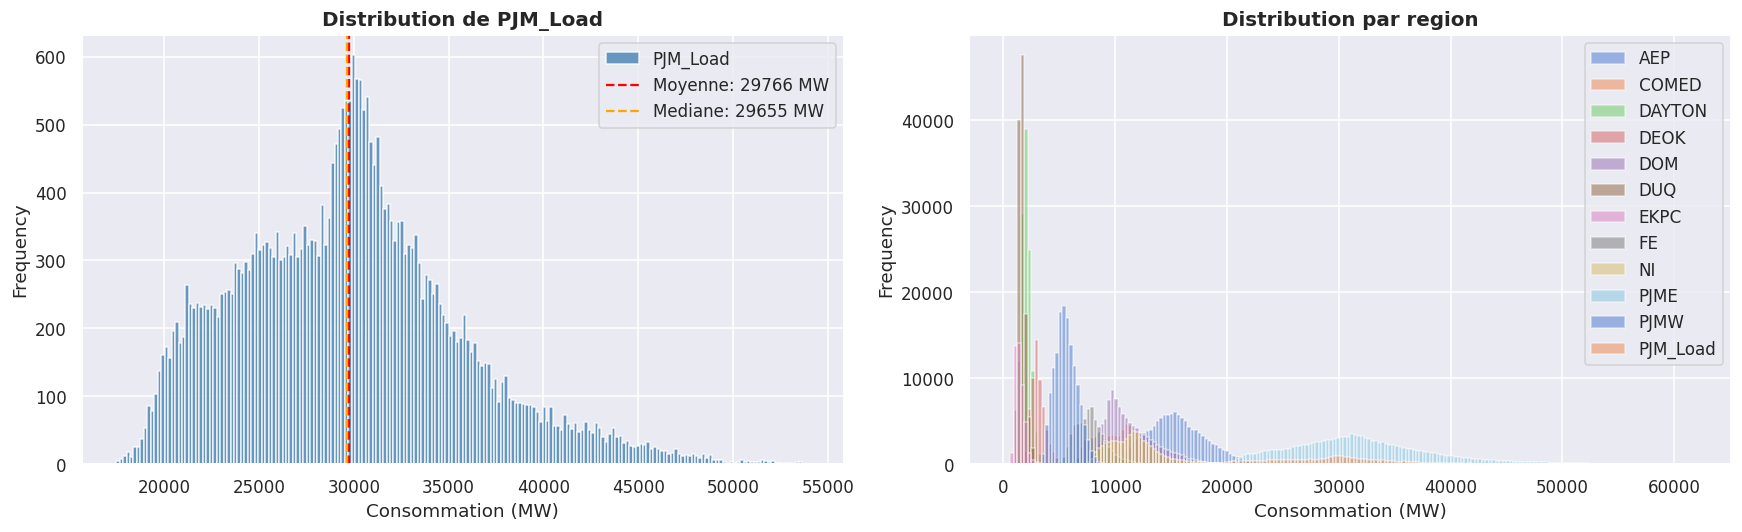

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['PJM_Load'].plot.hist(ax=axes[0], bins=200, color='steelblue', alpha=0.8)
axes[0].set_title('Distribution de PJM_Load', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Consommation (MW)')
axes[0].axvline(df['PJM_Load'].mean(), color='red', linestyle='--',
                label=f"Moyenne: {df['PJM_Load'].mean():.0f} MW")
axes[0].axvline(df['PJM_Load'].median(), color='orange', linestyle='--',
                label=f"Mediane: {df['PJM_Load'].median():.0f} MW")
axes[0].legend()

df.plot.hist(ax=axes[1], bins=200, alpha=0.5)
axes[1].set_title('Distribution par region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Consommation (MW)')
plt.tight_layout()
plt.show()

### 3.2 Evolution temporelle sur 20 ans

On observe la consommation de toutes les regions sur la totalite de la periode disponible.

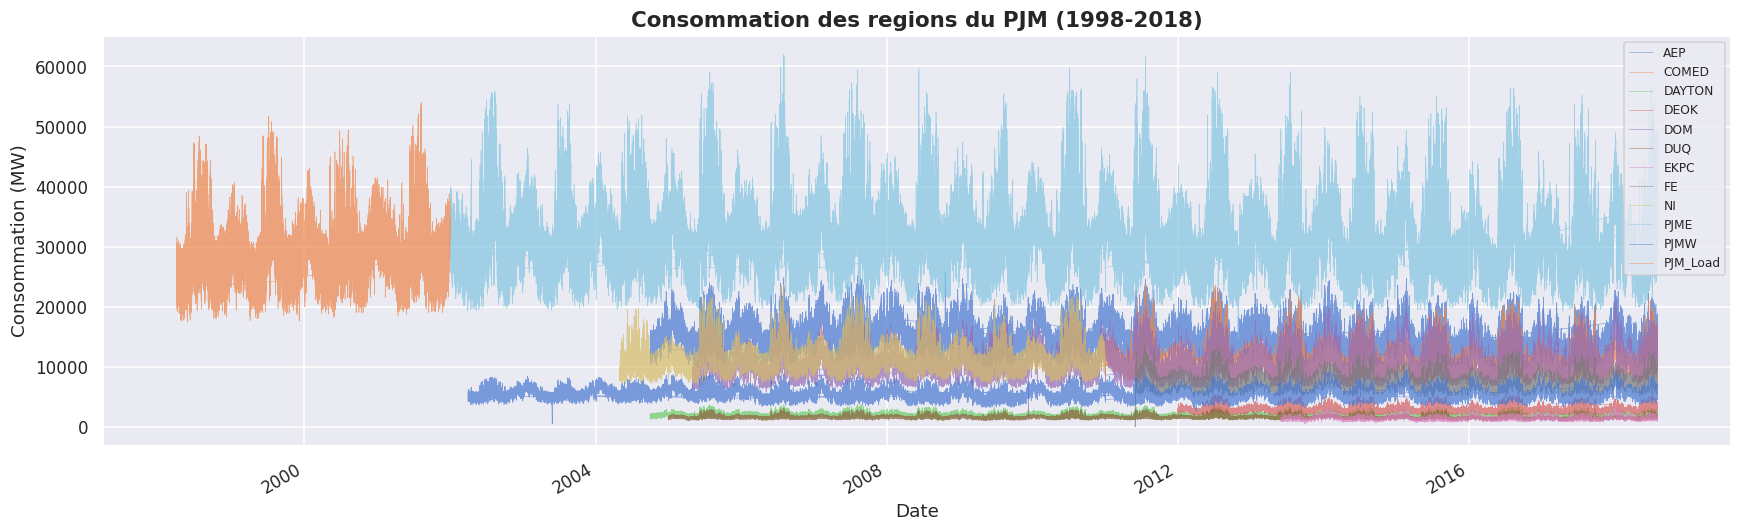

Observation : tendance stable avec de fortes oscillations saisonnieres.


In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
df.plot(ax=ax, alpha=0.7, linewidth=0.4)
ax.set_title('Consommation des regions du PJM (1998-2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation (MW)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
print('Observation : tendance stable avec de fortes oscillations saisonnieres.')

### 3.3 Zoom sur une annee type (2016 - region AEP)

En zoomant sur une seule annee, on identifie clairement les **pics saisonniers** :
- **Ete** : consommation elevee due a la climatisation
- **Hiver** : consommation elevee due au chauffage

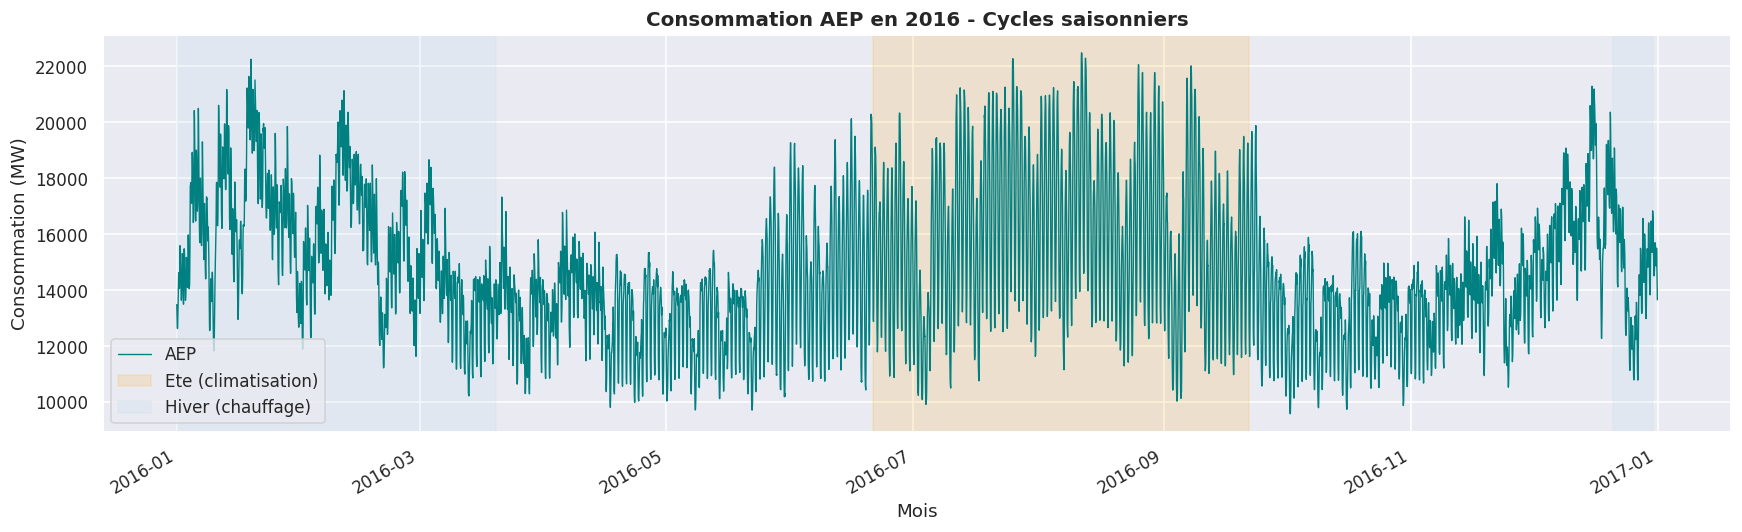

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))
aep_2016 = df['AEP'].sort_index().loc['2016-01-01':'2016-12-31']
aep_2016.plot(ax=ax, color='teal', linewidth=0.9)
ax.set_title('Consommation AEP en 2016 - Cycles saisonniers', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Consommation (MW)')
ax.axvspan('2016-06-21', '2016-09-22', alpha=0.15, color='orange', label='Ete (climatisation)')
ax.axvspan('2016-12-21', '2016-12-31', alpha=0.15, color='lightblue', label='Hiver (chauffage)')
ax.axvspan('2016-01-01', '2016-03-20', alpha=0.15, color='lightblue')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Patterns intra-journaliers et hebdomadaires

Ces patterns sont exactement ce que Prophet va apprendre :
- **Pattern journalier** : la consommation suit un cycle avec un pic en soiree
- **Pattern hebdomadaire** : chute nette le week-end (fermeture des entreprises)

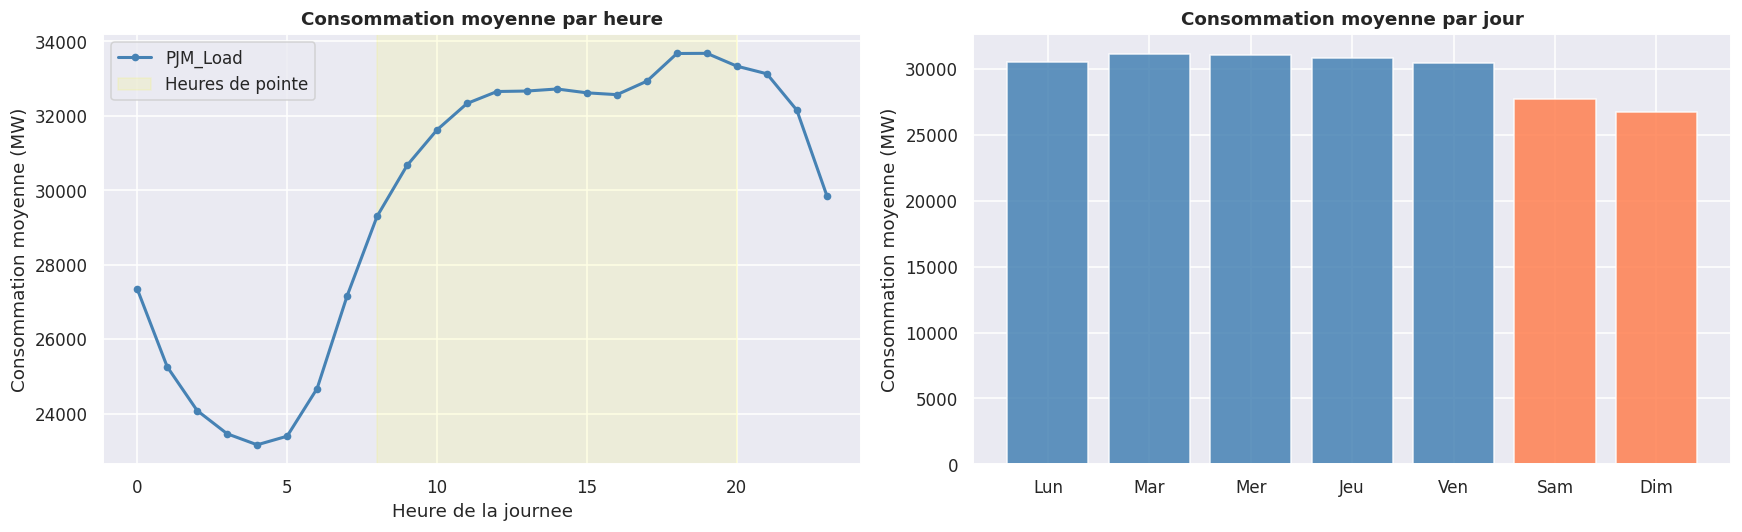

In [12]:
df['hour']    = df.index.hour
df['weekday'] = df.index.weekday
df['month']   = df.index.month
df['year']    = df.index.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.groupby('hour')['PJM_Load'].mean().plot(
    ax=axes[0], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Consommation moyenne par heure', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heure de la journee')
axes[0].set_ylabel('Consommation moyenne (MW)')
axes[0].axvspan(8, 20, alpha=0.1, color='yellow', label='Heures de pointe')
axes[0].legend()

jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
weekly = df.groupby('weekday')['PJM_Load'].mean()
axes[1].bar(range(7), weekly, color=['steelblue']*5+['coral']*2, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(jours)
axes[1].set_title('Consommation moyenne par jour', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Consommation moyenne (MW)')
plt.tight_layout()
plt.show()

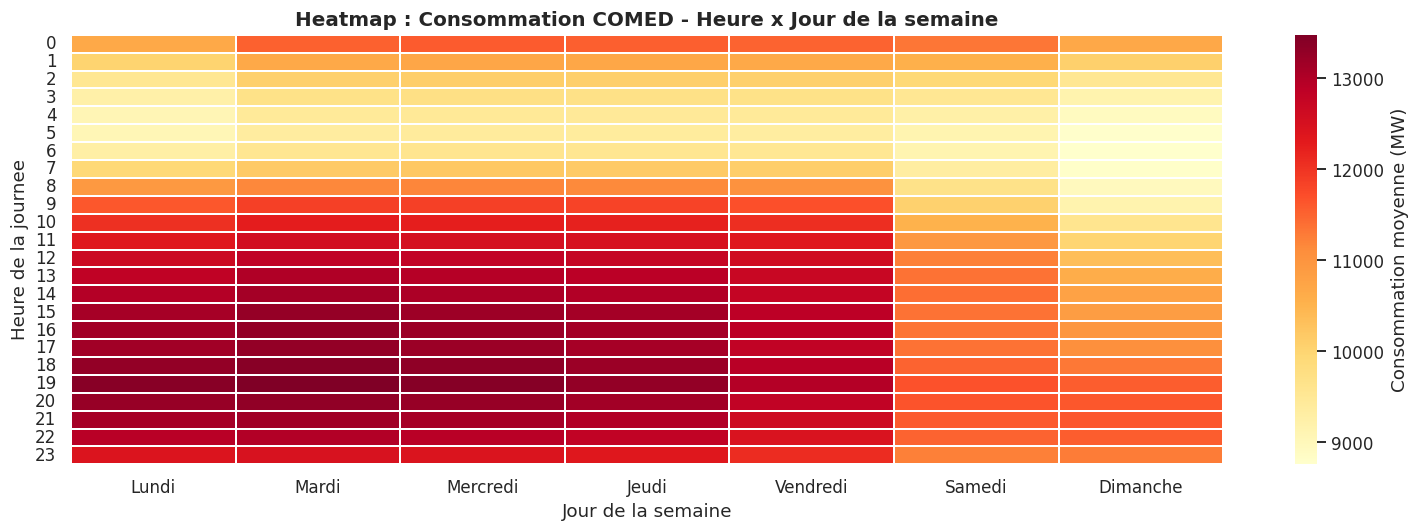

Les pics se concentrent en semaine entre 8h et 20h.


In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
pivot = df.pivot_table(index='hour', columns='weekday', values='COMED', aggfunc='mean')
pivot.columns = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Consommation moyenne (MW)'})
ax.set_title('Heatmap : Consommation COMED - Heure x Jour de la semaine', fontsize=13, fontweight='bold')
ax.set_xlabel('Jour de la semaine')
ax.set_ylabel('Heure de la journee')
plt.tight_layout()
plt.show()
print('Les pics se concentrent en semaine entre 8h et 20h.')

## 4. Decomposition de la Serie Temporelle

La **decomposition** separe la serie en 3 composantes :

| Composante | Description |
|-----------|-------------|
| **Tendance** | Direction generale sur le long terme |
| **Saisonnalite** | Patterns repetitifs a intervalles reguliers |
| **Residus** | Ce qui n'est pas explique par les deux precedents |

On resample en **donnees journalieres** pour rendre la decomposition plus lisible.

In [15]:
pjme = pd.read_csv('/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv',
                   index_col=[0], parse_dates=[0])
pjme = pjme.sort_index()

print(f'Dataset PJME :')
print(f'  Periode  : {pjme.index.min()} -> {pjme.index.max()}')
print(f'  Lignes   : {len(pjme):,}')
print(f'  Min      : {pjme["PJME_MW"].min():,.0f} MW')
print(f'  Max      : {pjme["PJME_MW"].max():,.0f} MW')
pjme.head()

Dataset PJME :
  Periode  : 2002-01-01 01:00:00 -> 2018-08-03 00:00:00
  Lignes   : 145,366
  Min      : 14,544 MW
  Max      : 62,009 MW


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


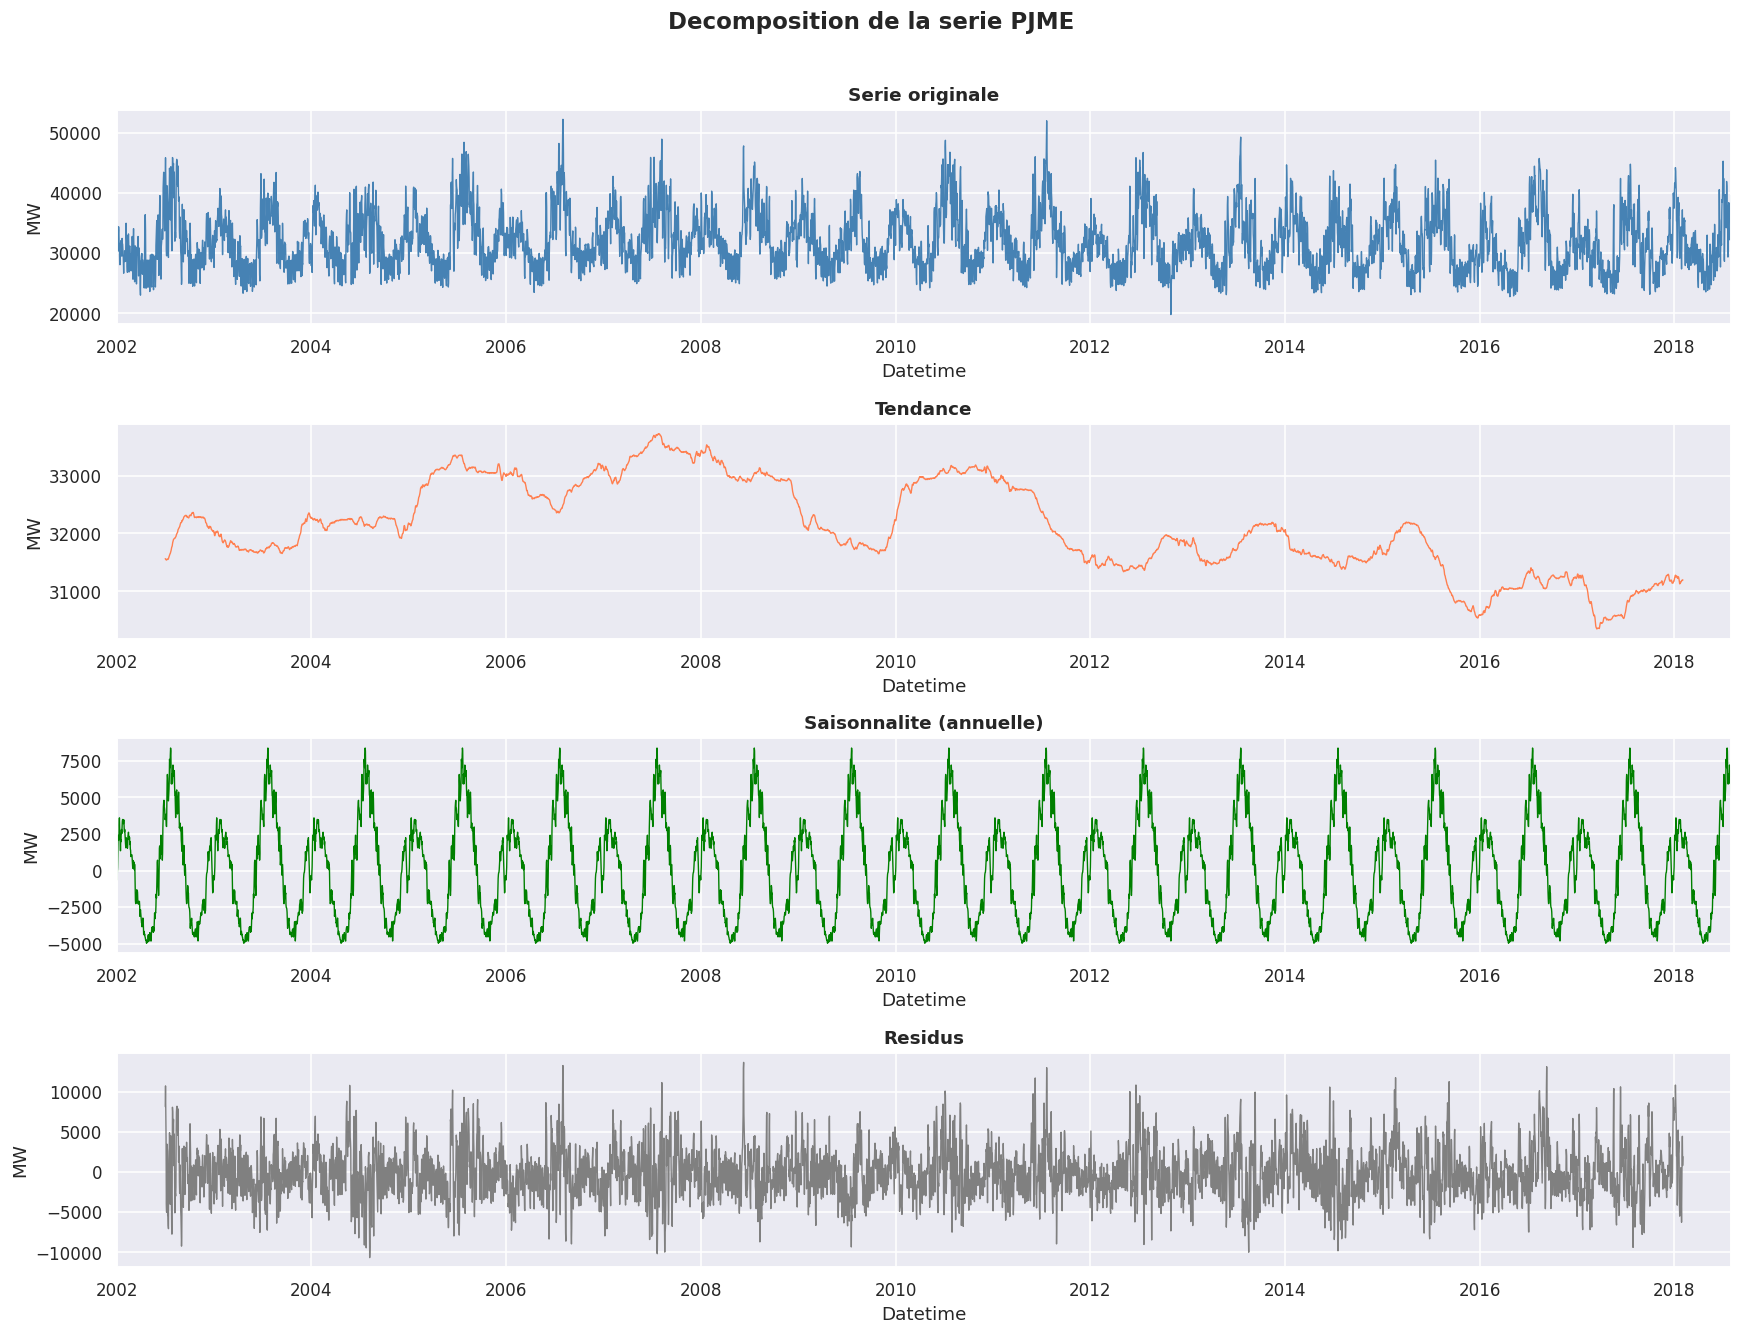

In [16]:
pjme_daily = pjme.resample('D').mean()
decomp = seasonal_decompose(pjme_daily['PJME_MW'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
labels = ['Serie originale', 'Tendance', 'Saisonnalite (annuelle)', 'Residus']
colors = ['steelblue', 'coral', 'green', 'gray']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]

for ax, comp, lbl, col in zip(axes, components, labels, colors):
    comp.plot(ax=ax, color=col, linewidth=0.9)
    ax.set_title(lbl, fontweight='bold')
    ax.set_ylabel('MW')

plt.suptitle('Decomposition de la serie PJME', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Split Train / Test

On divise les donnees temporellement :
- **Train** : 1998 -> 01/01/2016 (~18 ans)
- **Test**  : 01/01/2016 -> 2018 (~2 ans)

> **Important** : le split doit etre **chronologique strict**. Un split aleatoire entrainerait une **fuite de donnees** (*data leakage*) en laissant le modele apprendre depuis le futur.

Train : 122,687 obs (2002 -> 2016)
Test  : 22,679 obs (2016 -> 2018)
Ratio : 84.4% train / 15.6% test


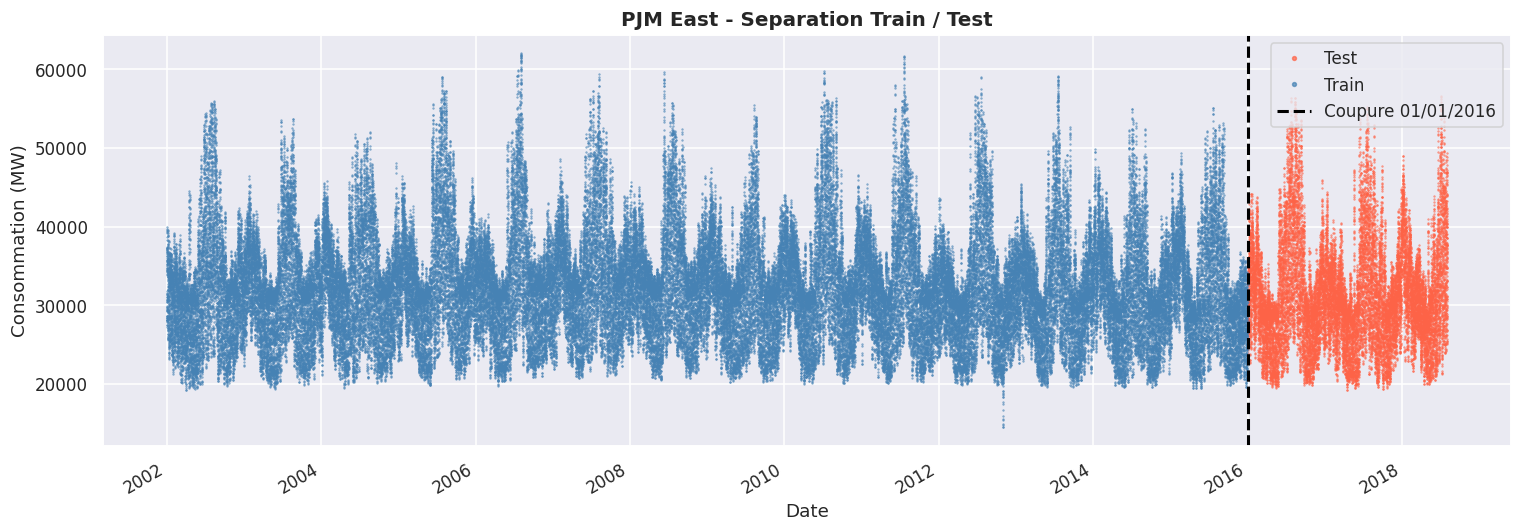

In [17]:
split_date = '2016-01-01'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test  = pjme.loc[pjme.index > split_date].copy()

print(f'Train : {len(pjme_train):,} obs ({pjme_train.index.min().year} -> {pjme_train.index.max().year})')
print(f'Test  : {len(pjme_test):,} obs ({pjme_test.index.min().year} -> {pjme_test.index.max().year})')
print(f'Ratio : {len(pjme_train)/len(pjme)*100:.1f}% train / {len(pjme_test)/len(pjme)*100:.1f}% test')

fig, ax = plt.subplots(figsize=(14, 5))
pjme_test.rename(columns={'PJME_MW': 'Test'}).join(
    pjme_train.rename(columns={'PJME_MW': 'Train'}), how='outer'
).plot(ax=ax, style='.', ms=1, alpha=0.7, color=['tomato','steelblue'])
ax.axvline(pd.to_datetime(split_date), color='black', linestyle='--', linewidth=2, label='Coupure 01/01/2016')
ax.set_title('PJM East - Separation Train / Test', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation (MW)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 6. Entrainement du Modele Prophet

### Preparation des donnees

Prophet attend un DataFrame avec exactement deux colonnes :
- `ds` : les timestamps (datetime)
- `y` : les valeurs a predire

On utilise `seasonality_mode='multiplicative'` car l'amplitude des oscillations est proportionnelle au niveau de la serie - ce qui est typique pour la consommation electrique.

In [18]:
pjme_train_prophet = (pjme_train.reset_index()
    .rename(columns={'Datetime':'ds','PJME_MW':'y'}))
pjme_test_prophet = (pjme_test.reset_index()
    .rename(columns={'Datetime':'ds','PJME_MW':'y'}))

print('Format requis par Prophet :')
pjme_train_prophet.head()

Format requis par Prophet :


,ds,y
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [19]:
%%time
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='multiplicative'
)
model.fit(pjme_train_prophet)
print('Modele entraine avec succes !')

21:13:53 - cmdstanpy - INFO - Chain [1] start processing
21:16:04 - cmdstanpy - INFO - Chain [1] done processing


Modele entraine avec succes !
CPU times: user 5.81 s, sys: 733 ms, total: 6.54 s
Wall time: 2min 17s


## 7. Predictions

Prophet genere pour chaque timestamp :
- `yhat` : prediction centrale
- `yhat_lower` / `yhat_upper` : intervalles de confiance a 80%

In [20]:
pjme_test_fcst = model.predict(pjme_test_prophet)
print(f'{len(pjme_test_fcst)} predictions generees')
pjme_test_fcst[['ds','yhat','yhat_lower','yhat_upper']].head(10)

22679 predictions generees


,ds,yhat,yhat_lower,yhat_upper
0,2016-01-01 01:00:00,28227.698496,23705.353167,32743.377223
1,2016-01-01 02:00:00,26770.664447,22301.665927,31427.856358
2,2016-01-01 03:00:00,25924.004514,21562.905650,30676.662230
3,2016-01-01 04:00:00,25782.216754,21228.052559,29951.348063
4,2016-01-01 05:00:00,26427.130450,21450.615551,30812.286870
5,2016-01-01 06:00:00,27813.593976,23339.112869,32632.290545
6,2016-01-01 07:00:00,29668.855055,25055.100225,34292.713639
7,2016-01-01 08:00:00,31547.053874,26892.656732,36188.303216
8,2016-01-01 09:00:00,33037.367691,28496.828423,37377.973384
9,2016-01-01 10:00:00,33968.804254,29421.519590,38347.417766


### 7.1 Visualisation mensuelle - Mars 2017

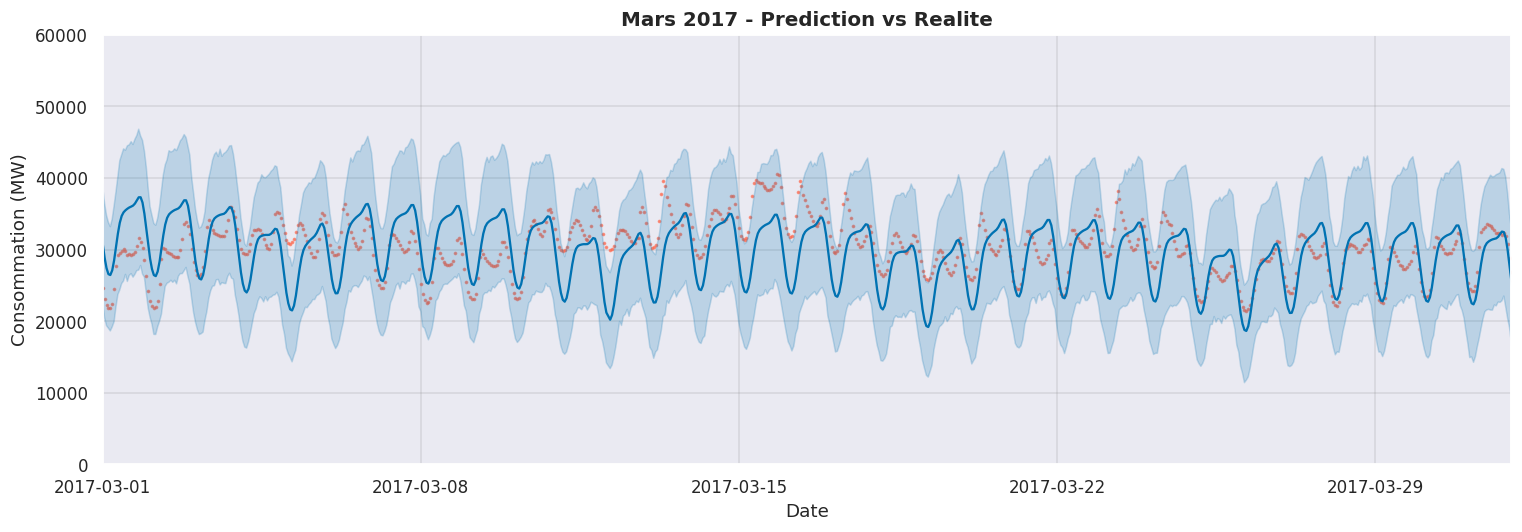

In [21]:
start = pd.to_datetime('2017-03-01')
end   = pd.to_datetime('2017-04-01')
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='tomato', s=2, alpha=0.6, label='Reel')
model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=start, upper=end)
ax.set_ylim(0, 60000)
ax.set_title('Mars 2017 - Prediction vs Realite', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation (MW)')
plt.tight_layout()
plt.show()

### 7.2 Zoom hebdomadaire - 1ere semaine de Mars 2017

En zoomant sur une semaine, on voit clairement :
- Les **pics journaliers** (soirees en semaine)
- La **chute du week-end** (samedi-dimanche)

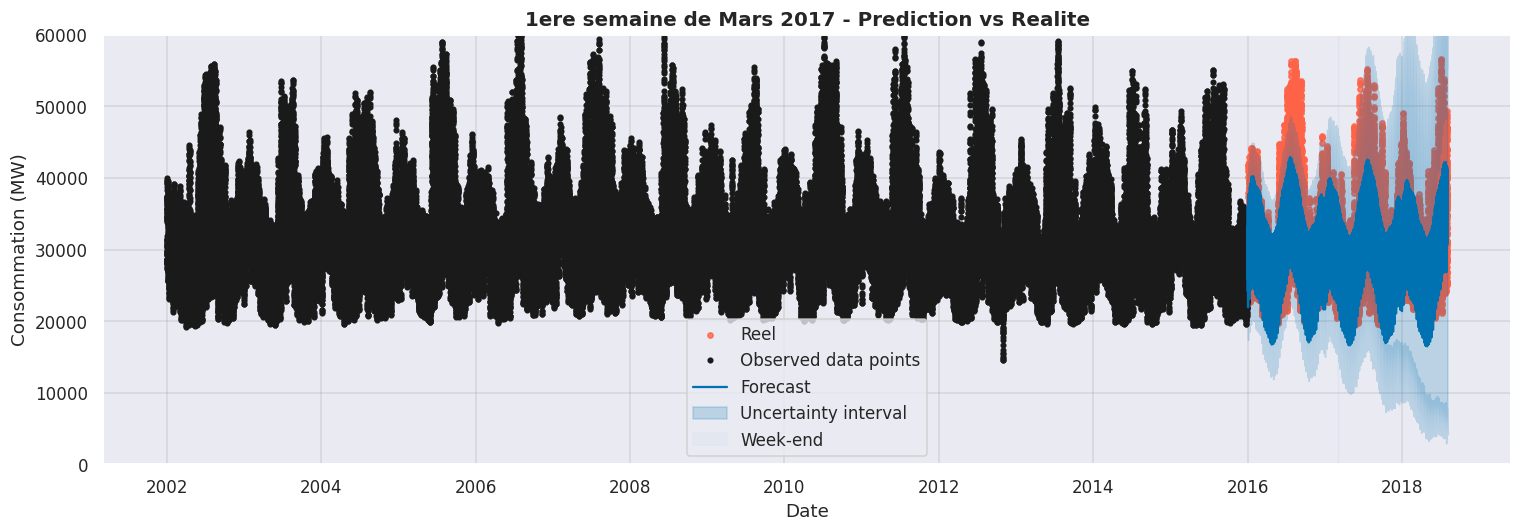

In [22]:
start = pd.to_datetime('2017-03-01')
end   = pd.to_datetime('2017-03-08')
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='tomato', s=12, alpha=0.8, label='Reel')
model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower=start, upper=end)
ax.set_ylim(0, 60000)
ax.axvspan('2017-03-04', '2017-03-06', alpha=0.1, color='lightblue', label='Week-end')
ax.set_title('1ere semaine de Mars 2017 - Prediction vs Realite', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation (MW)')
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Decomposition des composantes apprises

L'un des grands avantages de Prophet est son **interpretabilite** : on peut visualiser chaque composante du modele separement.

Cela permet de valider que le modele a bien appris les patterns metier :
- Tendance de long terme
- Saisonnalites annuelle, hebdomadaire et journaliere

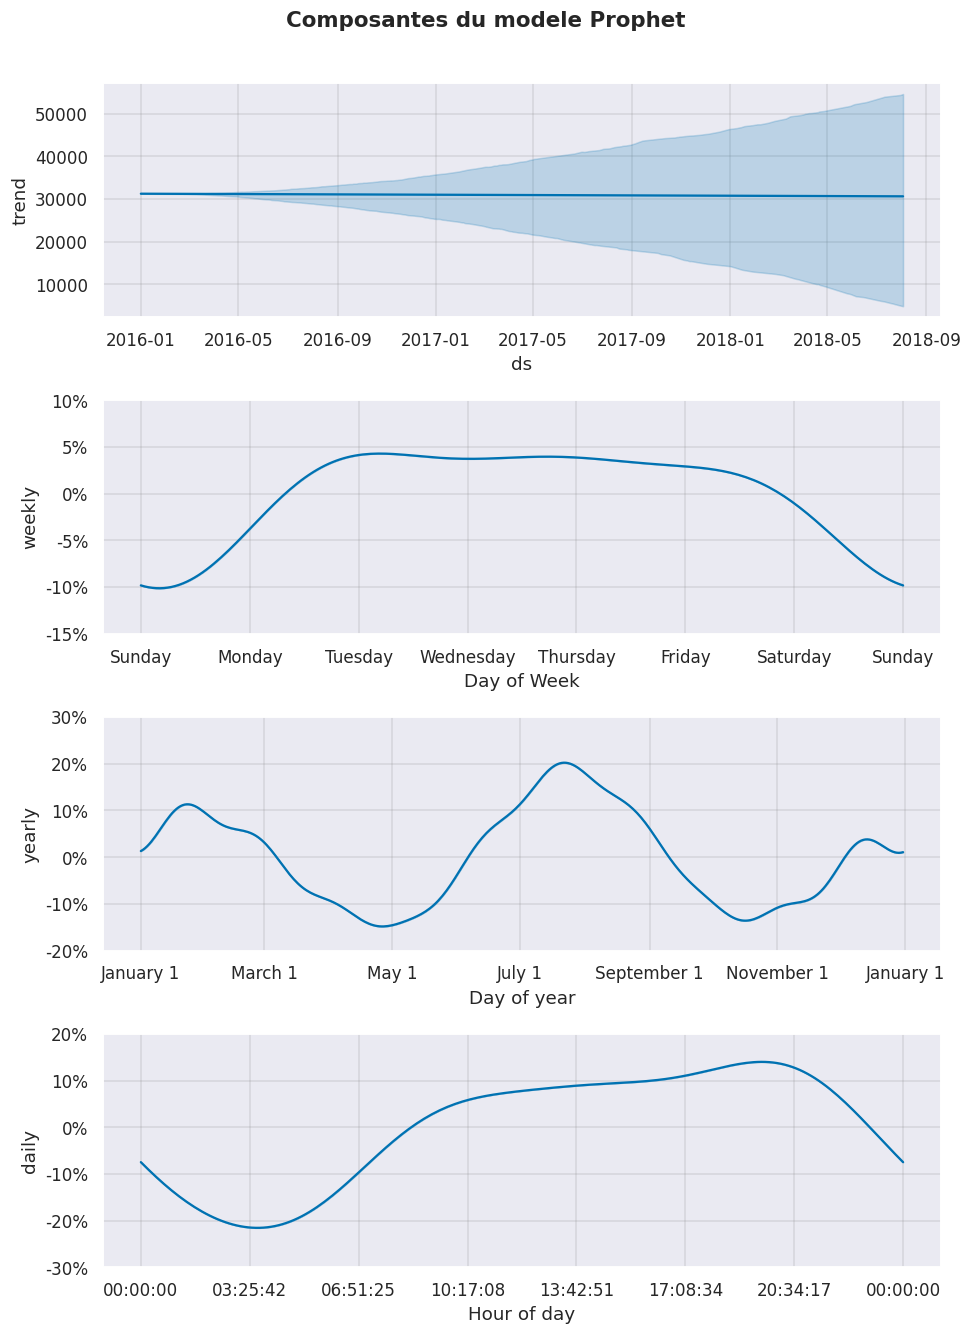

Interpretation :
  Tendance annuelle    : legere decroissance -> efficacite energetique en hausse
  Saisonnalite annuelle: deux pics (ete + hiver)
  Saisonnalite hebdo   : chute nette le week-end
  Saisonnalite journaliere : pic en soiree (~17h-20h)


In [23]:
fig = model.plot_components(pjme_test_fcst)
fig.suptitle('Composantes du modele Prophet', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Interpretation :')
print('  Tendance annuelle    : legere decroissance -> efficacite energetique en hausse')
print('  Saisonnalite annuelle: deux pics (ete + hiver)')
print('  Saisonnalite hebdo   : chute nette le week-end')
print('  Saisonnalite journaliere : pic en soiree (~17h-20h)')

## 8. Evaluation des Performances

### Metriques utilisees

| Metrique | Formule | Interpretation |
|----------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Sensible aux grosses erreurs |
| **MAE**  | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Erreur absolue moyenne, robuste |
| **MAPE** | $\frac{100}{n}\sum\frac{|y_i - \hat{y}_i|}{y_i}$ | Erreur relative en % |

Un **MAPE < 10%** est generalement considere comme excellent pour la prevision energetique.

In [24]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

y_true = pjme_test['PJME_MW']
y_pred = pjme_test_fcst['yhat']

rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
mae_v  = mean_absolute_error(y_true, y_pred)
mape_v = mape(y_true, y_pred)

print('=' * 45)
print('     RESULTATS DU MODELE PROPHET')
print('=' * 45)
print(f'  RMSE  : {rmse_v:,.0f} MW')
print(f'  MAE   : {mae_v:,.0f} MW')
print(f'  MAPE  : {mape_v:.2f} %')
print('=' * 45)
print(f'  Conso moyenne reelle : {y_true.mean():,.0f} MW')

     RESULTATS DU MODELE PROPHET
  RMSE  : 4,079 MW
  MAE   : 3,102 MW
  MAPE  : 9.70 %
  Conso moyenne reelle : 31,173 MW


### 8.1 Analyse des residus

Les residus doivent ressembler a un bruit blanc : **aleatoires, centres sur 0, de variance constante**.

Des patterns persistants dans les residus revelent des informations que le modele n'a pas capturees.

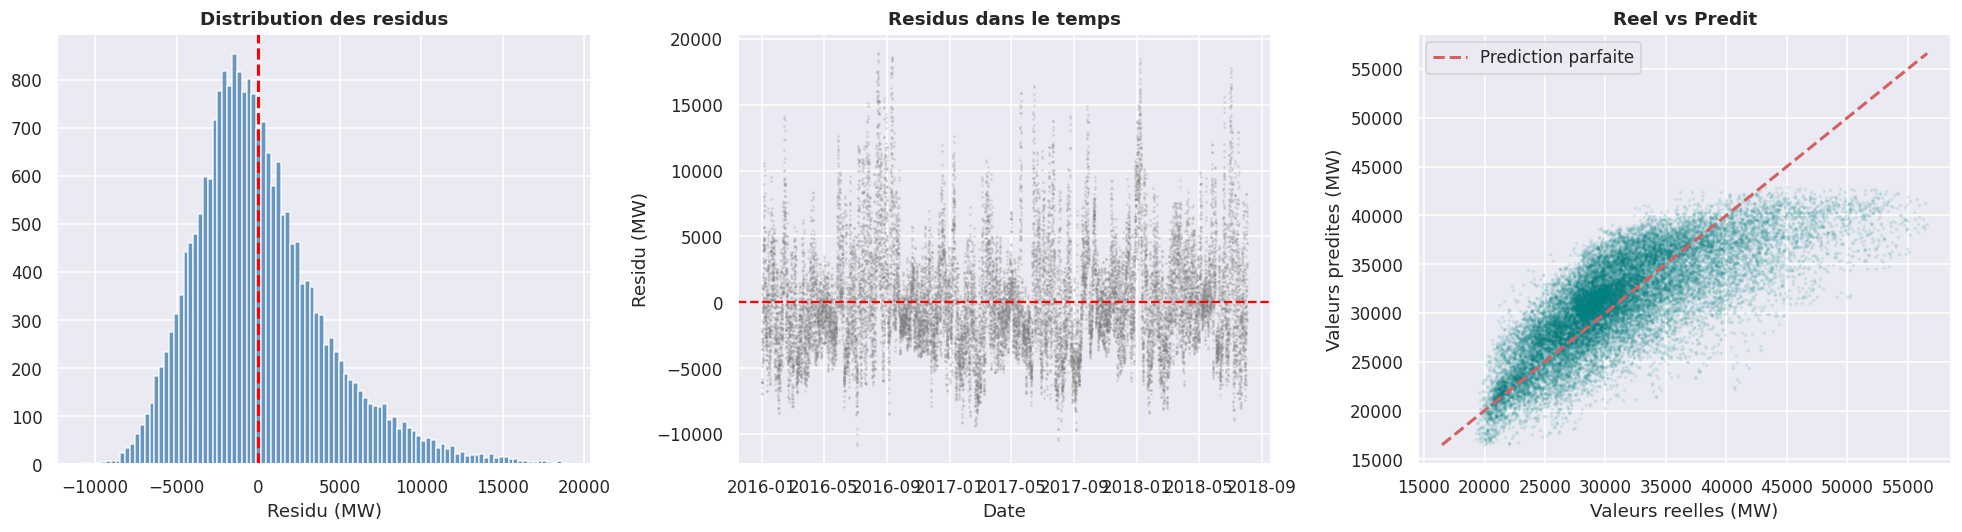

Biais moyen : 142.6 MW
Ecart-type  : 4076.8 MW


In [25]:
residuals = y_true.values - y_pred.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution des residus', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residu (MW)')

axes[1].scatter(pjme_test.index, residuals, alpha=0.15, s=1, color='gray')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residus dans le temps', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residu (MW)')

axes[2].scatter(y_true, y_pred, alpha=0.08, s=2, color='teal')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[2].plot(lims, lims, 'r--', linewidth=2, label='Prediction parfaite')
axes[2].set_title('Reel vs Predit', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valeurs reelles (MW)')
axes[2].set_ylabel('Valeurs predites (MW)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Biais moyen : {residuals.mean():.1f} MW')
print(f'Ecart-type  : {residuals.std():.1f} MW')

## 9. Amelioration : Ajout des Jours Feries

Les **jours feries americains** (Thanksgiving, Labor Day, Christmas...) perturbent fortement les patterns habituels de consommation electrique.

Prophet permet de les integrer nativement via `add_country_holidays()`. On compare les deux modeles cote a cote.

In [26]:
%%time
model_h = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='multiplicative'
)
model_h.add_country_holidays(country_name='US')
model_h.fit(pjme_train_prophet)

fcst_h   = model_h.predict(pjme_test_prophet)
y_pred_h = fcst_h['yhat']

rmse_h = np.sqrt(mean_squared_error(y_true, y_pred_h))
mae_h  = mean_absolute_error(y_true, y_pred_h)
mape_h = mape(y_true, y_pred_h)

print('=' * 60)
print('   Comparaison : Sans jours feries vs Avec jours feries')
print('=' * 60)
print(f"{'Metrique':<10} {'Sans feries':>16} {'Avec feries':>16} {'Delta':>10}")
print('-' * 60)
print(f"{'RMSE':<10} {rmse_v:>16,.0f} {rmse_h:>16,.0f} {rmse_h-rmse_v:>+10,.0f}")
print(f"{'MAE':<10} {mae_v:>16,.0f} {mae_h:>16,.0f} {mae_h-mae_v:>+10,.0f}")
print(f"{'MAPE':<10} {mape_v:>15.2f}% {mape_h:>15.2f}% {mape_h-mape_v:>+9.2f}%")
print('=' * 60)

amelioration = mape_v - mape_h
if amelioration > 0:
    print(f'Ajout des jours feries : amelioration de {amelioration:.2f} points de MAPE')
else:
    print(f'Difference negligeable ({amelioration:.2f} points)')

21:17:55 - cmdstanpy - INFO - Chain [1] start processing
21:20:49 - cmdstanpy - INFO - Chain [1] done processing


   Comparaison : Sans jours feries vs Avec jours feries
Metrique        Sans feries      Avec feries      Delta
------------------------------------------------------------
RMSE                  4,079            4,057        -22
MAE                   3,102            3,083        -19
MAPE                  9.70%            9.63%     -0.07%
Ajout des jours feries : amelioration de 0.07 points de MAPE
CPU times: user 11.5 s, sys: 1.13 s, total: 12.7 s
Wall time: 3min 5s


## 10. Conclusion & Pistes d'Amelioration

### Ce que nous avons accompli

- **Analyse exploratoire complete** de 20 ans de donnees de consommation electrique
- **Identification des patterns** : journalier, hebdomadaire, annuel et saisonniers
- **Decomposition** de la serie en tendance, saisonnalite et residus
- **Entrainement et evaluation** d'un modele Prophet avec metriques rigoureuses
- **Amelioration** via l'integration des jours feries americains

---

### Pistes d'Amelioration

**1. Donnees meteo comme variables externes**

La temperature est le principal driver de la consommation electrique. Prophet supporte les regresseurs externes :

```python
model.add_regressor('temperature')
```

**2. XGBoost / LightGBM avec feature engineering**

Avec des features temporelles (heure, mois, saison, lags, moyennes mobiles), un modele gradient boosting surpasse souvent Prophet sur les series energetiques.

**3. Deep Learning (LSTM / Temporal Fusion Transformer)**

Des architectures neuronales peuvent capturer des dependances complexes que Prophet ne voit pas.

**4. Validation croisee temporelle**

Prophet integre une methode `cross_validation()` pour evaluer la robustesse :

```python
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(model, initial='3650 days', period='180 days', horizon='365 days')
```

**5. Hyperparameter tuning**

Optimiser `changepoint_prior_scale` et `seasonality_prior_scale` via une grid search.

---

### References

- [Prophet Documentation](https://facebook.github.io/prophet/docs/quick_start.html)
- [Dataset Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)
- Taylor & Letham (2018), *Forecasting at Scale*, The American Statistician
